In [7]:
import os
import pathlib
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
# Ruta archivo CSV
file_path = Path(
    r"C:\Users\juans\OneDrive\Documentos\Maestria en Ingenieria y Analitica de Datos\Proyecto de Grado\CineMate AI\data\raw\chatbot_sessions_raw.csv"
)

# Cargar CSV
df = pd.read_csv(file_path, encoding="utf-8-sig")

# Validación rápida
print("Archivo cargado correctamente")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

# Vista previa
df.head()

Archivo cargado correctamente
Filas: 11
Columnas: 21


,session_id,user_id,created_at,session_mode,session_use_rag,interaction_number,timestamp,query,routed_query,mode,...,used_cache,latency_ms,results_count,title_response,score_response,csat_score,nps_score,nps_category,resolution_label,resolution_numeric
0,0d2944f1-d1dc-441b-ac4c-d722ea02b38c,57 316 7556912,2026-04-13,RAG,True,1,19:33,recomiendame algo como pacific rim,recomiendame algo como pacific rim,RAG,...,False,0.010224,5,Pacific Rim,0.4023,5,10,promoter,yes,3
1,0d2944f1-d1dc-441b-ac4c-d722ea02b38c,57 316 7556912,2026-04-13,RAG,True,2,19:53,ya las vi,ya las vi,RAG,...,False,0.017754,5,The Las Vegas Story,0.3925,5,10,promoter,yes,3
2,6d5b775c-4fa9-4f61-bd49-a36a0982fd5f,57 316 7556912,2026-04-15,DIRECT,False,1,23:06,recomiendame algo parecido a transformers,recomiendame algo parecido a transformers,DIRECT,...,False,0.006766,5,Babcock Transformers,0.4141,5,10,promoter,yes,3
3,7251b23c-d3e2-4530-a4a2-8609c257f67d,57 316 7556912,2026-04-16,RAG,True,1,02:36,recomiendame algo como pacific rim,recomiendame algo como pacific rim,RAG,...,False,0.002578,5,Pacific Rim,0.4023,5,7,passive,yes,3
4,a5646d83-cec6-48af-93be-c7bde3698897,57 316 7556912,2026-04-15,RAG,True,1,22:42,recomiendame algo parecido a tranformers,recomiendame algo parecido a tranformers,RAG,...,False,0.005460,5,Humans,0.1979,5,10,promoter,yes,3


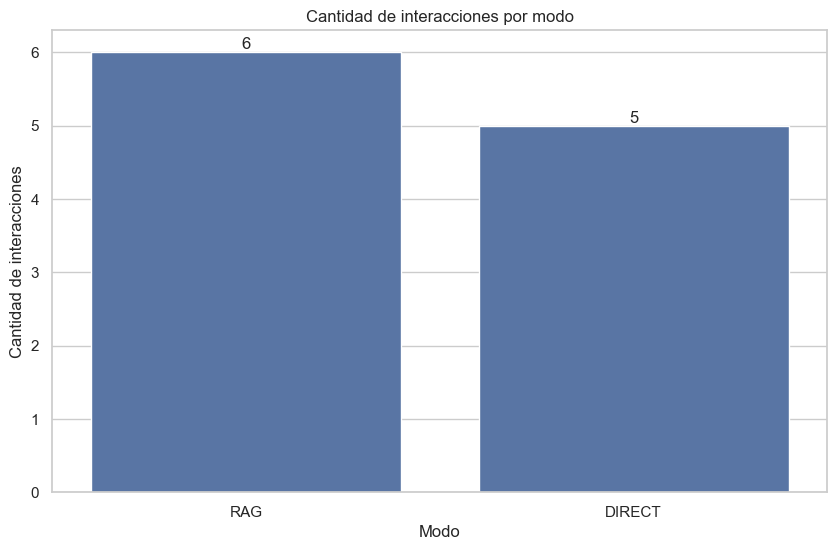

In [9]:
# =====================================================
# BLOQUE A - DISTRIBUCIÓN DE USO
# =====================================================

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ---------------------------------
# Gráfica 1: Cantidad de interacciones por modo
# ---------------------------------

interactions_mode = df["mode"].value_counts().reset_index()
interactions_mode.columns = ["mode", "count"]

plt.figure()
sns.barplot(data=interactions_mode, x="mode", y="count")

plt.title("Cantidad de interacciones por modo")
plt.xlabel("Modo")
plt.ylabel("Cantidad de interacciones")

for i, row in interactions_mode.iterrows():
    plt.text(i, row["count"], row["count"], ha="center", va="bottom")

plt.show()


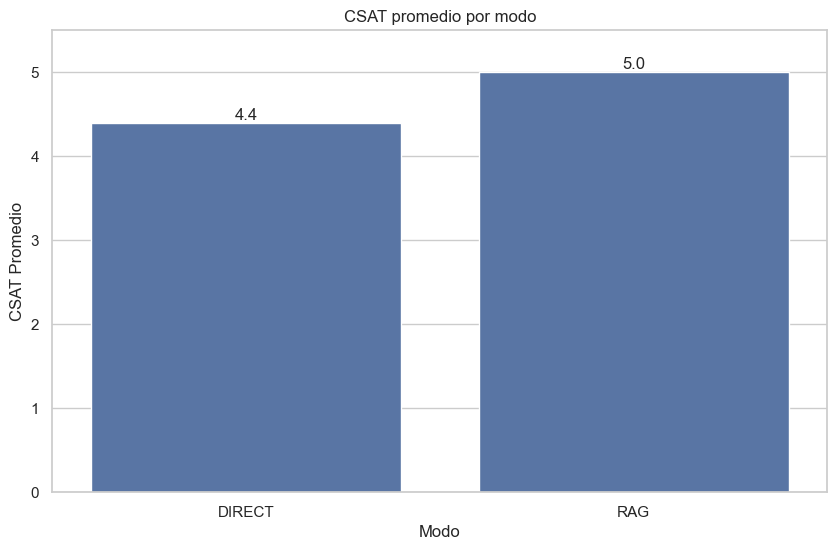

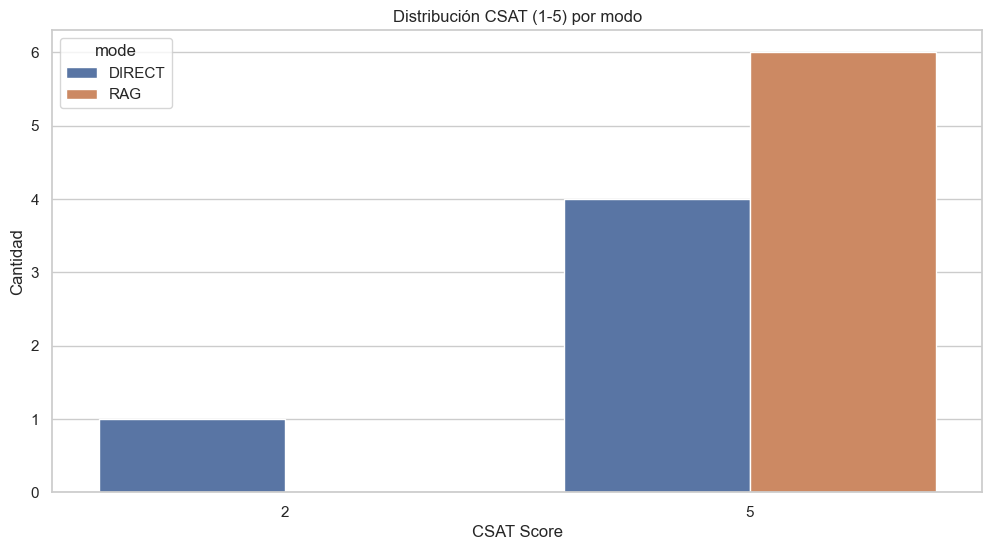

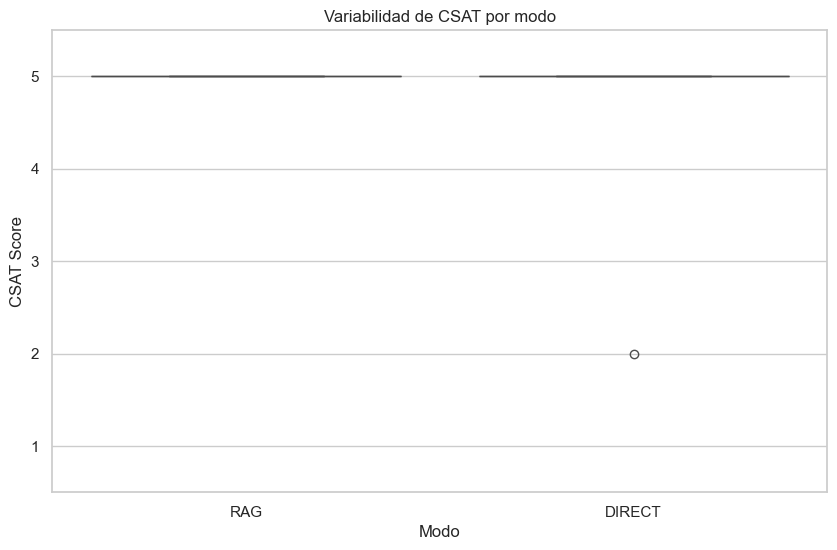

In [10]:
# =====================================================
# BLOQUE B - SATISFACCIÓN DEL USUARIO
# =====================================================

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Base con feedback válido
df_csat = df[df["csat_score"].notna()].copy()

# ---------------------------------
# Gráfica 1: CSAT promedio por modo
# ---------------------------------

csat_mean = (
    df_csat.groupby("mode")["csat_score"]
    .mean()
    .reset_index()
)

plt.figure()
sns.barplot(data=csat_mean, x="mode", y="csat_score")

plt.title("CSAT promedio por modo")
plt.xlabel("Modo")
plt.ylabel("CSAT Promedio")

for i, row in csat_mean.iterrows():
    plt.text(i, row["csat_score"], round(row["csat_score"], 2),
             ha="center", va="bottom")

plt.ylim(0, 5.5)
plt.show()


# ---------------------------------
# Gráfica 2: Distribución CSAT por modo
# ---------------------------------

csat_dist = (
    df_csat.groupby(["mode", "csat_score"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(12,6))
sns.barplot(data=csat_dist, x="csat_score", y="count", hue="mode")

plt.title("Distribución CSAT (1-5) por modo")
plt.xlabel("CSAT Score")
plt.ylabel("Cantidad")
plt.show()


# ---------------------------------
# Gráfica 3: Boxplot CSAT por modo
# ---------------------------------

plt.figure()
sns.boxplot(data=df_csat, x="mode", y="csat_score")

plt.title("Variabilidad de CSAT por modo")
plt.xlabel("Modo")
plt.ylabel("CSAT Score")

plt.ylim(0.5, 5.5)
plt.show()

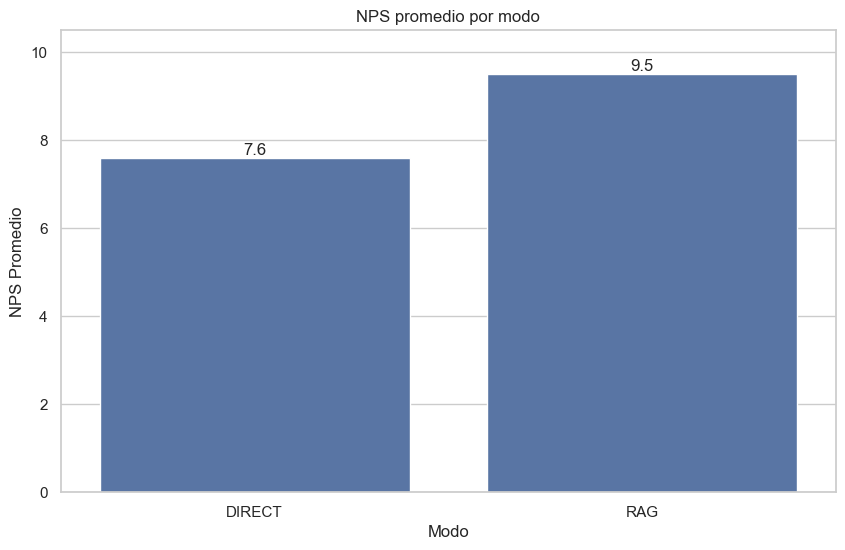

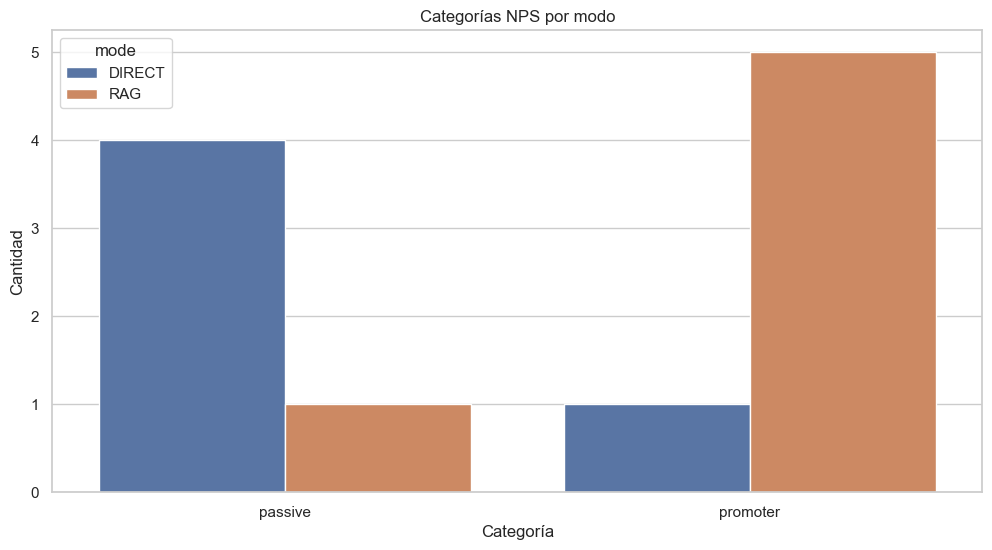

In [11]:
# =====================================================
# BLOQUE C - NPS
# =====================================================

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Base con NPS válido
df_nps = df[df["nps_score"].notna()].copy()

# ---------------------------------
# Gráfica 1: NPS promedio por modo
# ---------------------------------

nps_mean = (
    df_nps.groupby("mode")["nps_score"]
    .mean()
    .reset_index()
)

plt.figure()
sns.barplot(data=nps_mean, x="mode", y="nps_score")

plt.title("NPS promedio por modo")
plt.xlabel("Modo")
plt.ylabel("NPS Promedio")

for i, row in nps_mean.iterrows():
    plt.text(i, row["nps_score"], round(row["nps_score"], 2),
             ha="center", va="bottom")

plt.ylim(0, 10.5)
plt.show()


# ---------------------------------
# Gráfica 2: Categorías NPS por modo
# ---------------------------------

df_nps["nps_category"] = df_nps["nps_category"].fillna("unknown")

nps_cat = (
    df_nps.groupby(["mode", "nps_category"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(12,6))
sns.barplot(data=nps_cat, x="nps_category", y="count", hue="mode")

plt.title("Categorías NPS por modo")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")

plt.show()

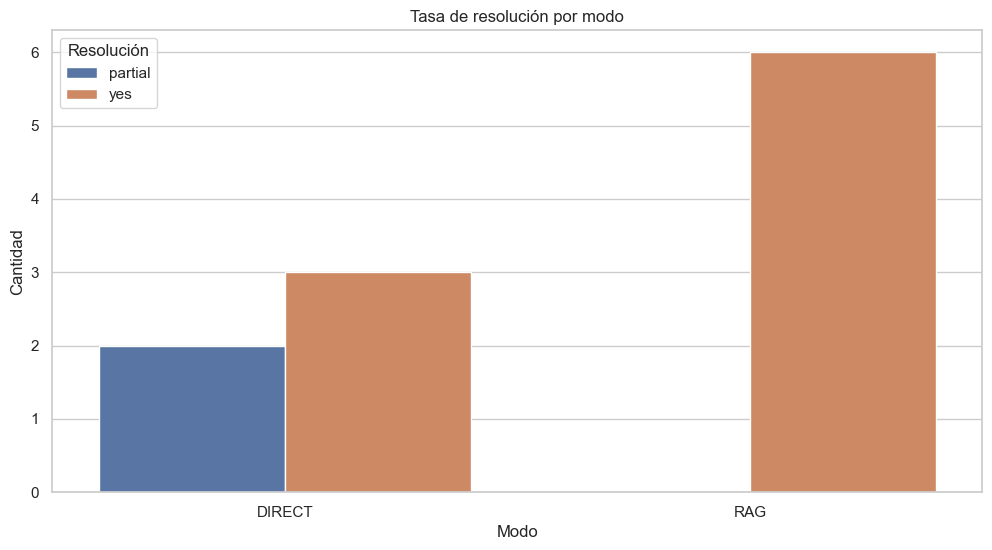

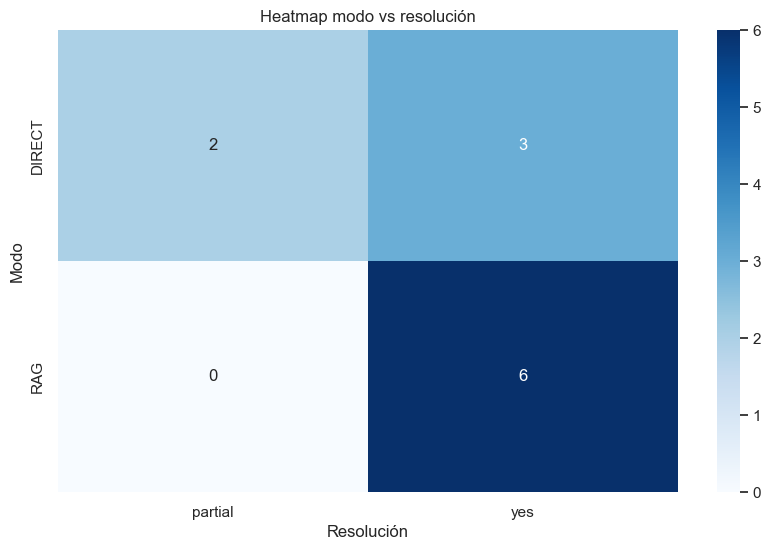

In [12]:
# =====================================================
# BLOQUE D - RESOLUCIÓN DEL PROBLEMA
# =====================================================

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Base con resolución válida
df_res = df[df["resolution_label"].notna()].copy()

# ---------------------------------
# Gráfica 1: Tasa de resolución por modo
# ---------------------------------

resolution_count = (
    df_res.groupby(["mode", "resolution_label"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=resolution_count,
    x="mode",
    y="count",
    hue="resolution_label"
)

plt.title("Tasa de resolución por modo")
plt.xlabel("Modo")
plt.ylabel("Cantidad")
plt.legend(title="Resolución")

plt.show()


# ---------------------------------
# Gráfica 2: Heatmap modo vs resolución
# ---------------------------------

heatmap_data = pd.crosstab(
    df_res["mode"],
    df_res["resolution_label"]
)

plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="g",
    cmap="Blues"
)

plt.title("Heatmap modo vs resolución")
plt.xlabel("Resolución")
plt.ylabel("Modo")

plt.show()

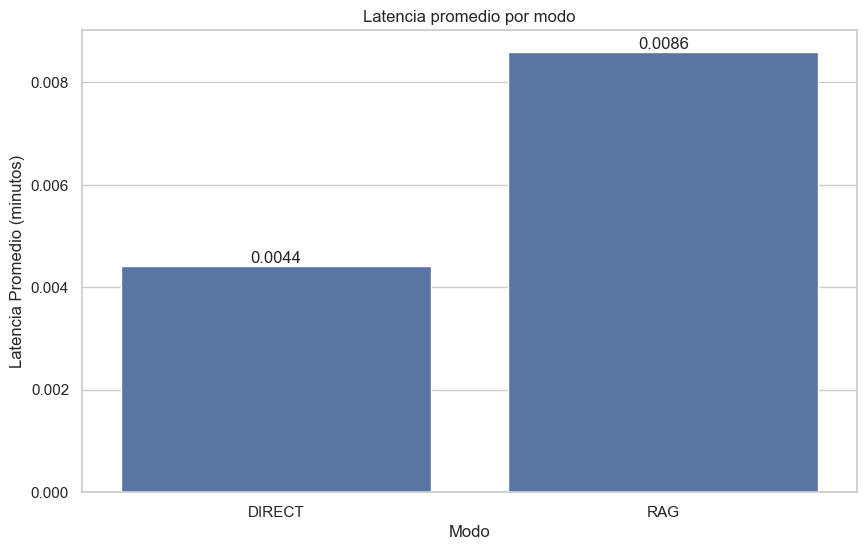

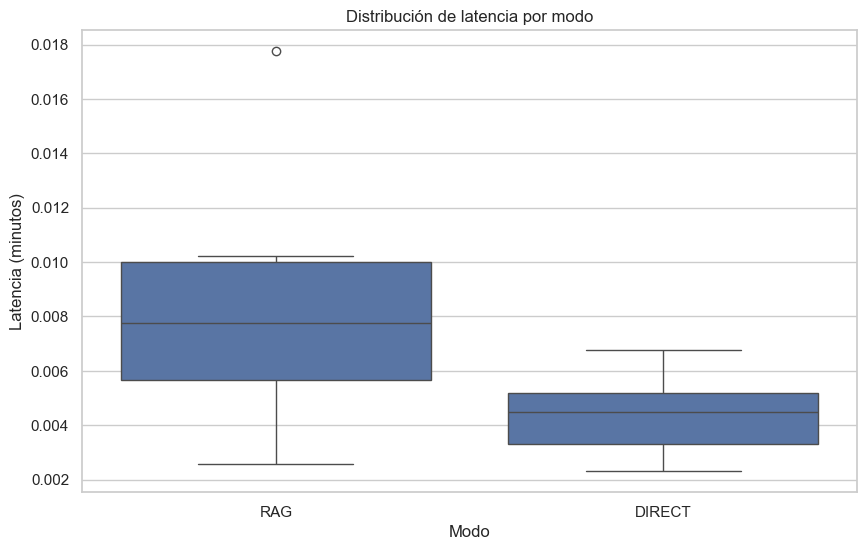

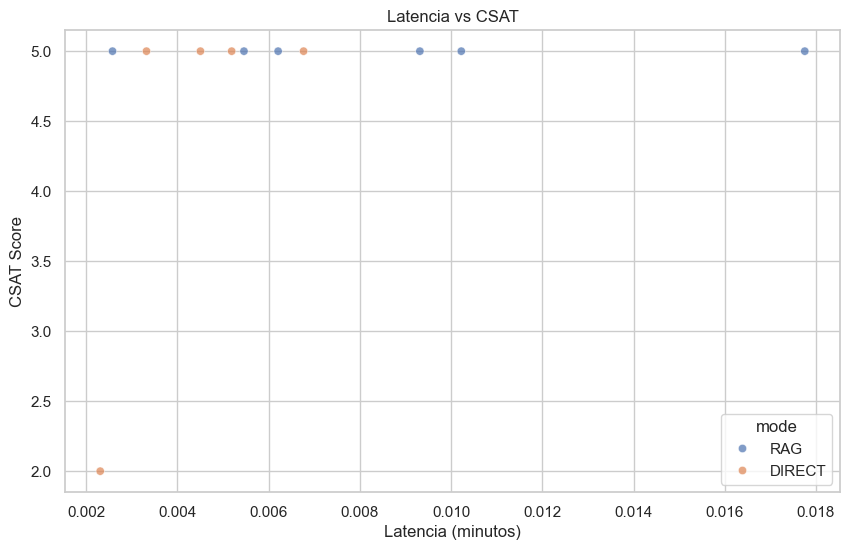

In [13]:
# =====================================================
# BLOQUE E - RENDIMIENTO TÉCNICO
# =====================================================

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Base con latencia válida
df_lat = df[df["latency_ms"].notna()].copy()

# ---------------------------------
# Gráfica 1: Latencia promedio por modo
# ---------------------------------

lat_mean = (
    df_lat.groupby("mode")["latency_ms"]
    .mean()
    .reset_index()
)

plt.figure()
sns.barplot(data=lat_mean, x="mode", y="latency_ms")

plt.title("Latencia promedio por modo")
plt.xlabel("Modo")
plt.ylabel("Latencia Promedio (minutos)")

for i, row in lat_mean.iterrows():
    plt.text(i, row["latency_ms"], round(row["latency_ms"], 4),
             ha="center", va="bottom")

plt.show()


# ---------------------------------
# Gráfica 2: Distribución de latencia por modo
# ---------------------------------

plt.figure()
sns.boxplot(data=df_lat, x="mode", y="latency_ms")

plt.title("Distribución de latencia por modo")
plt.xlabel("Modo")
plt.ylabel("Latencia (minutos)")

plt.show()


# ---------------------------------
# Gráfica 3: Latencia vs CSAT
# ---------------------------------

df_scatter = df[
    df["latency_ms"].notna() &
    df["csat_score"].notna()
].copy()

plt.figure()
sns.scatterplot(
    data=df_scatter,
    x="latency_ms",
    y="csat_score",
    hue="mode",
    alpha=0.7
)

plt.title("Latencia vs CSAT")
plt.xlabel("Latencia (minutos)")
plt.ylabel("CSAT Score")

plt.show()


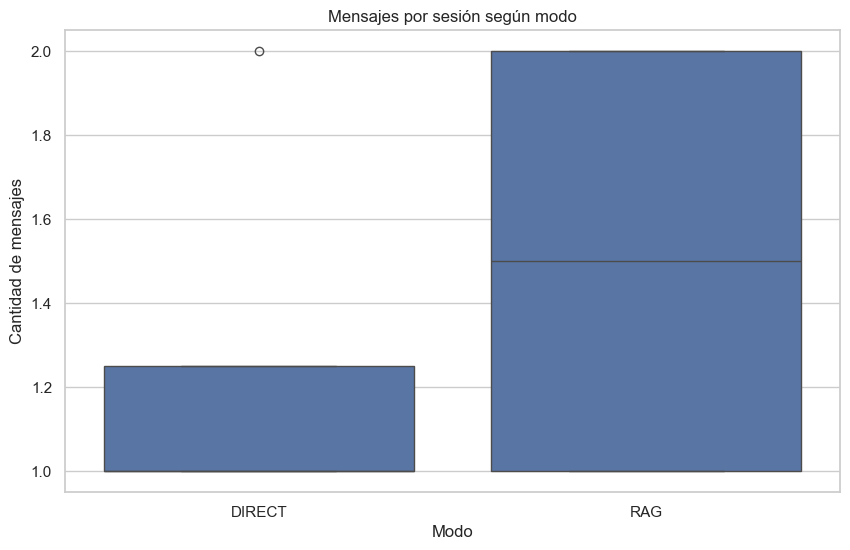

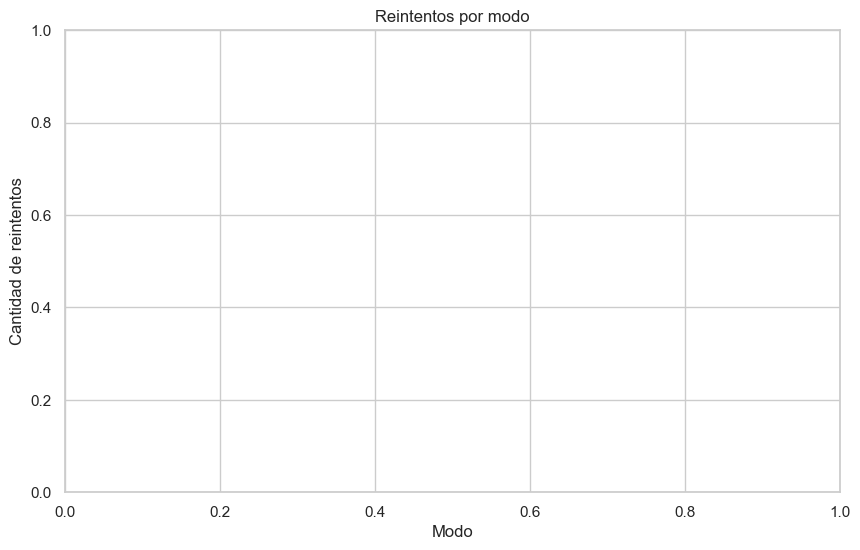

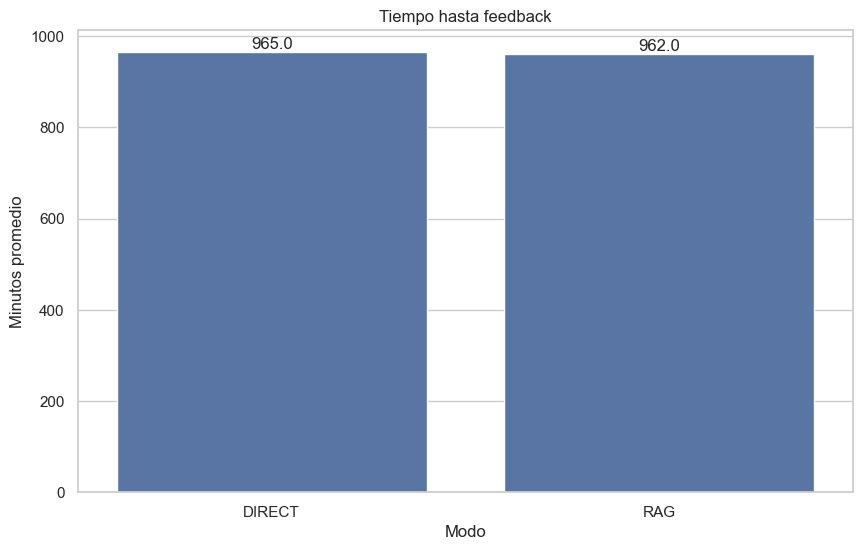

In [14]:
# =====================================================
# BLOQUE F - CONVERSACIÓN
# =====================================================

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ---------------------------------
# Gráfica 1: Mensajes por sesión según modo
# ---------------------------------

messages_session = (
    df.groupby(["mode", "session_id"])
    .size()
    .reset_index(name="messages_count")
)

plt.figure()
sns.boxplot(
    data=messages_session,
    x="mode",
    y="messages_count"
)

plt.title("Mensajes por sesión según modo")
plt.xlabel("Modo")
plt.ylabel("Cantidad de mensajes")

plt.show()


# ---------------------------------
# Gráfica 2: Reintentos por modo
# ---------------------------------

retry_words = [
    "otra",
    "otro",
    "ya la vi",
    "otra opción",
    "no me gusta",
    "más",
    "different"
]

df_retry = df[
    df["query"]
    .astype(str)
    .str.lower()
    .str.contains("|".join(retry_words), na=False)
].copy()

retry_count = (
    df_retry.groupby("mode")
    .size()
    .reset_index(name="count")
)

plt.figure()
sns.barplot(data=retry_count, x="mode", y="count")

plt.title("Reintentos por modo")
plt.xlabel("Modo")
plt.ylabel("Cantidad de reintentos")

for i, row in retry_count.iterrows():
    plt.text(i, row["count"], row["count"],
             ha="center", va="bottom")

plt.show()


# ---------------------------------
# Gráfica 3: Tiempo hasta feedback
# ---------------------------------

df_time = df[
    df["created_at"].notna() &
    df["timestamp"].notna() &
    df["csat_score"].notna()
].copy()

# Convertir a datetime temporalmente
df_time["created_at_dt"] = pd.to_datetime(df_time["created_at"], errors="coerce")
df_time["timestamp_dt"] = pd.to_datetime(df_time["timestamp"], format="%H:%M", errors="coerce")

# Diferencia estimada en minutos
df_time["minutes_to_feedback"] = (
    (df_time["timestamp_dt"] - df_time["timestamp_dt"].min())
    .dt.total_seconds() / 60
)

feedback_mode = (
    df_time.groupby("mode")["minutes_to_feedback"]
    .mean()
    .reset_index()
)

plt.figure()
sns.barplot(data=feedback_mode, x="mode", y="minutes_to_feedback")

plt.title("Tiempo hasta feedback")
plt.xlabel("Modo")
plt.ylabel("Minutos promedio")

for i, row in feedback_mode.iterrows():
    plt.text(i, row["minutes_to_feedback"], round(row["minutes_to_feedback"], 2),
             ha="center", va="bottom")

plt.show()

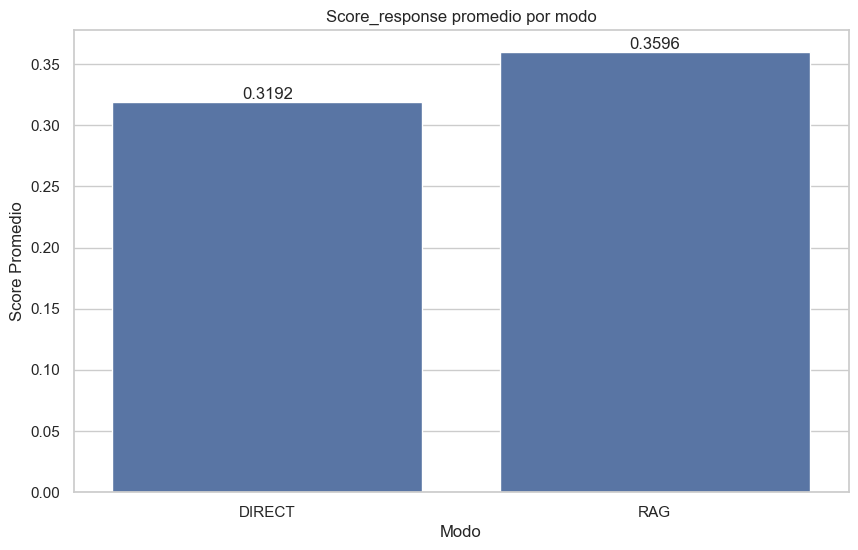

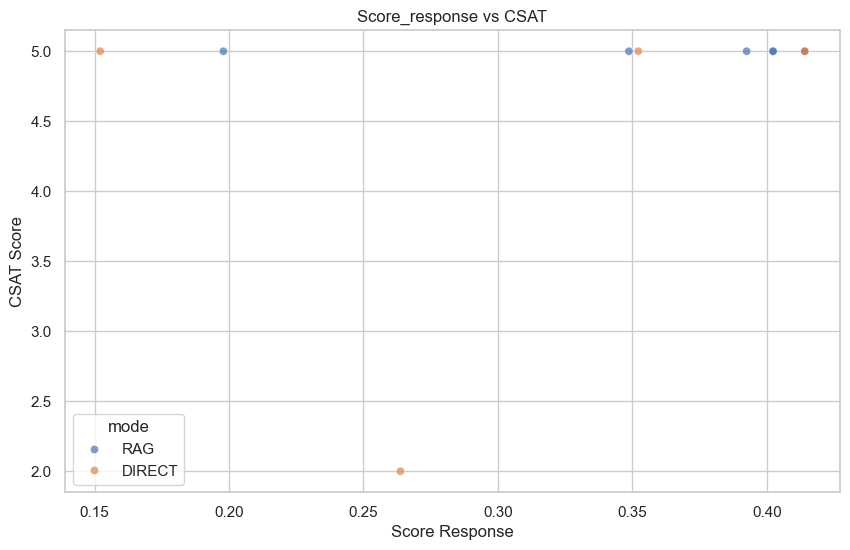

In [15]:
# =====================================================
# BLOQUE G - CALIDAD SEMÁNTICA
# =====================================================

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ---------------------------------
# Gráfica 1: Score_response promedio por modo
# ---------------------------------

df_score = df[df["score_response"].notna()].copy()

score_mean = (
    df_score.groupby("mode")["score_response"]
    .mean()
    .reset_index()
)

plt.figure()
sns.barplot(data=score_mean, x="mode", y="score_response")

plt.title("Score_response promedio por modo")
plt.xlabel("Modo")
plt.ylabel("Score Promedio")

for i, row in score_mean.iterrows():
    plt.text(i, row["score_response"], round(row["score_response"], 4),
             ha="center", va="bottom")

plt.show()


# ---------------------------------
# Gráfica 2: Score_response vs CSAT
# ---------------------------------

df_corr = df[
    df["score_response"].notna() &
    df["csat_score"].notna()
].copy()

plt.figure()
sns.scatterplot(
    data=df_corr,
    x="score_response",
    y="csat_score",
    hue="mode",
    alpha=0.7
)

plt.title("Score_response vs CSAT")
plt.xlabel("Score Response")
plt.ylabel("CSAT Score")

plt.show()

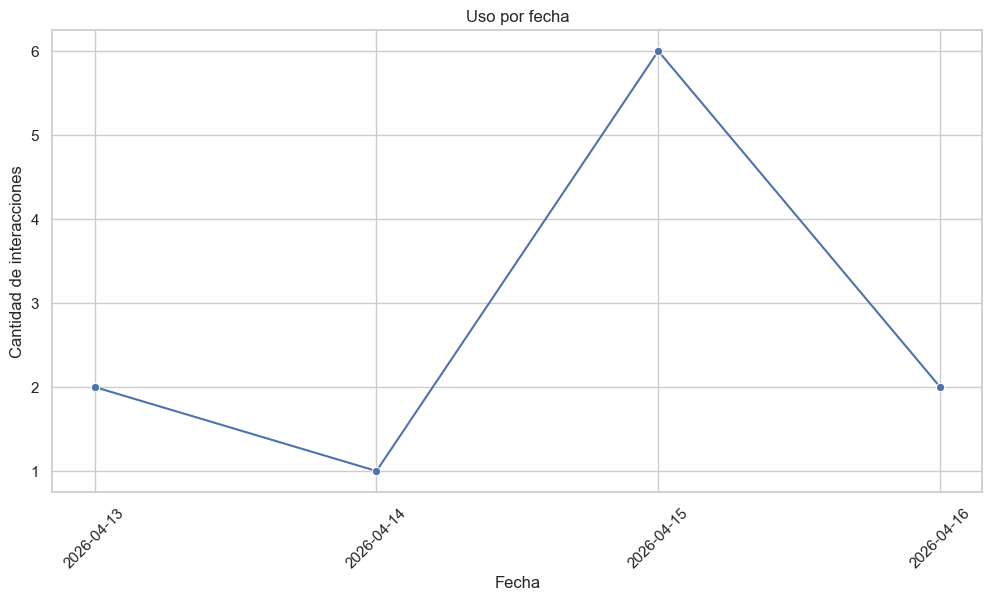

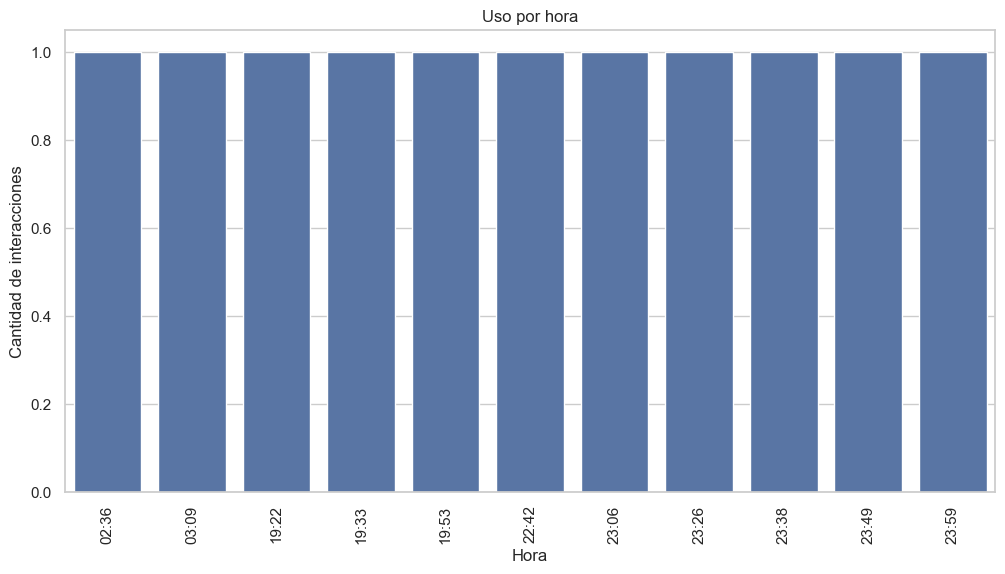

In [16]:
# =====================================================
# BLOQUE H - TEMPORAL
# =====================================================

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ---------------------------------
# Gráfica 1: Uso por fecha
# ---------------------------------

df_date = df[df["created_at"].notna()].copy()

usage_date = (
    df_date.groupby("created_at")
    .size()
    .reset_index(name="count")
    .sort_values("created_at")
)

plt.figure(figsize=(12,6))
sns.lineplot(data=usage_date, x="created_at", y="count", marker="o")

plt.title("Uso por fecha")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de interacciones")
plt.xticks(rotation=45)

plt.show()


# ---------------------------------
# Gráfica 2: Uso por hora
# ---------------------------------

df_hour = df[df["timestamp"].notna()].copy()

usage_hour = (
    df_hour.groupby("timestamp")
    .size()
    .reset_index(name="count")
    .sort_values("timestamp")
)

plt.figure(figsize=(12,6))
sns.barplot(data=usage_hour, x="timestamp", y="count")

plt.title("Uso por hora")
plt.xlabel("Hora")
plt.ylabel("Cantidad de interacciones")
plt.xticks(rotation=90)

plt.show()

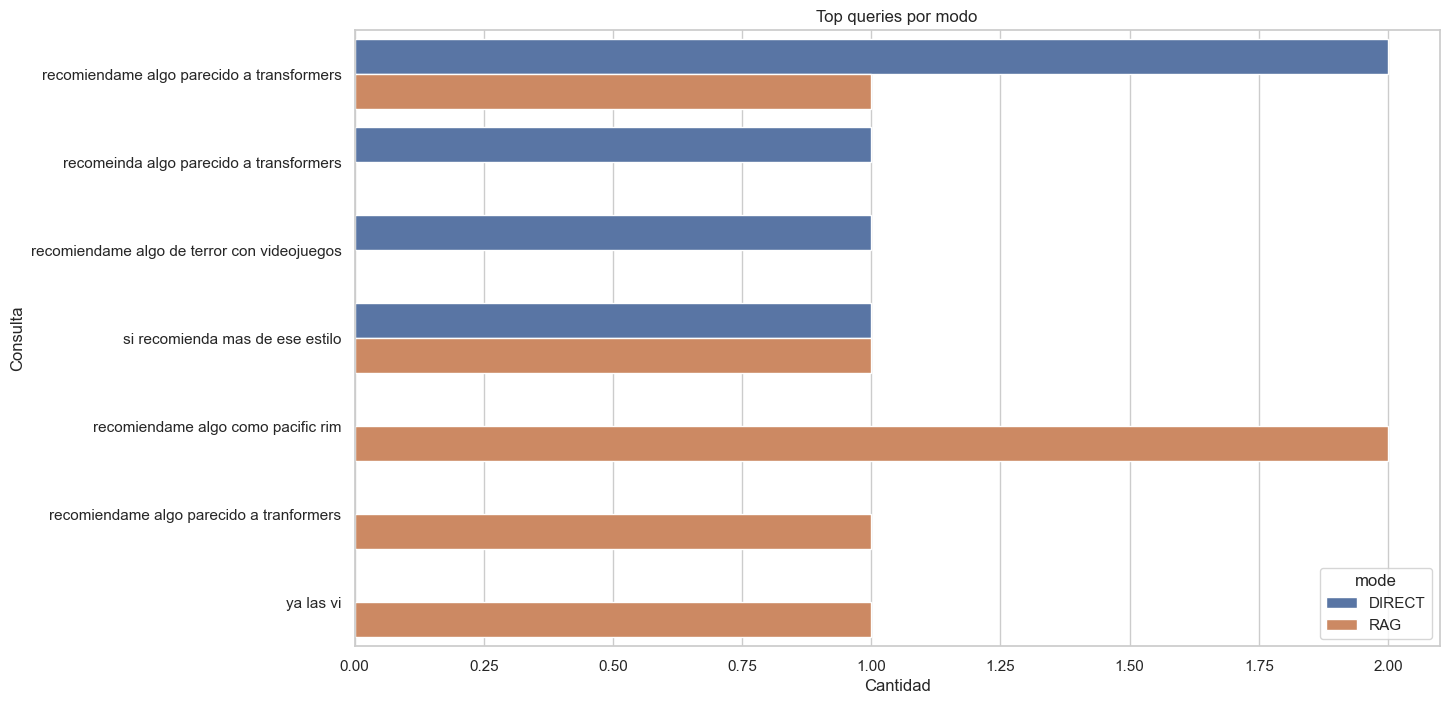

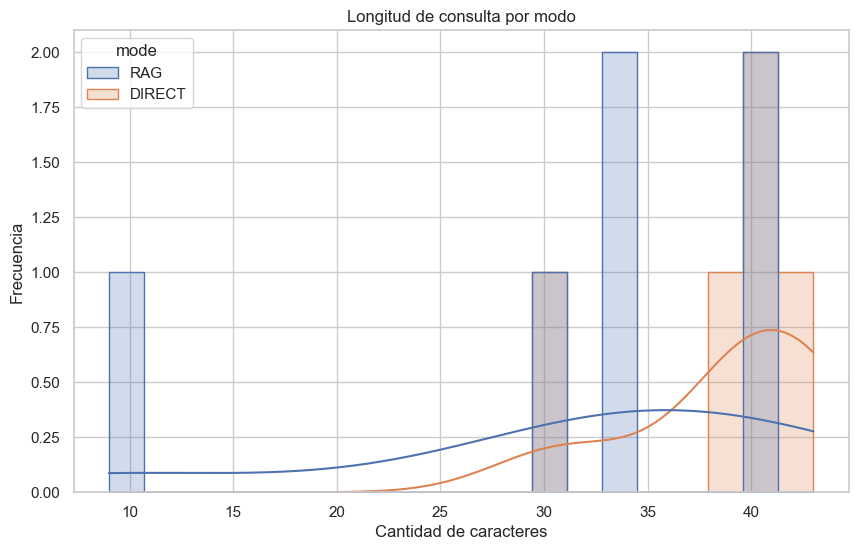

In [17]:
# =====================================================
# BLOQUE I - TEXTO / CONSULTAS
# =====================================================

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ---------------------------------
# Gráfica 1: Top queries por modo
# ---------------------------------

df_query = df[df["query"].notna()].copy()

top_queries = (
    df_query.groupby(["mode", "query"])
    .size()
    .reset_index(name="count")
)

top_queries = (
    top_queries.sort_values(
        ["mode", "count"],
        ascending=[True, False]
    )
    .groupby("mode")
    .head(10)
)

plt.figure(figsize=(14,8))
sns.barplot(
    data=top_queries,
    x="count",
    y="query",
    hue="mode"
)

plt.title("Top queries por modo")
plt.xlabel("Cantidad")
plt.ylabel("Consulta")

plt.show()


# ---------------------------------
# Gráfica 2: Longitud de consulta por modo
# ---------------------------------

df_len = df[df["query"].notna()].copy()

df_len["query_length"] = (
    df_len["query"]
    .astype(str)
    .str.len()
)

plt.figure()
sns.histplot(
    data=df_len,
    x="query_length",
    hue="mode",
    kde=True,
    bins=20,
    element="step"
)

plt.title("Longitud de consulta por modo")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")

plt.show()

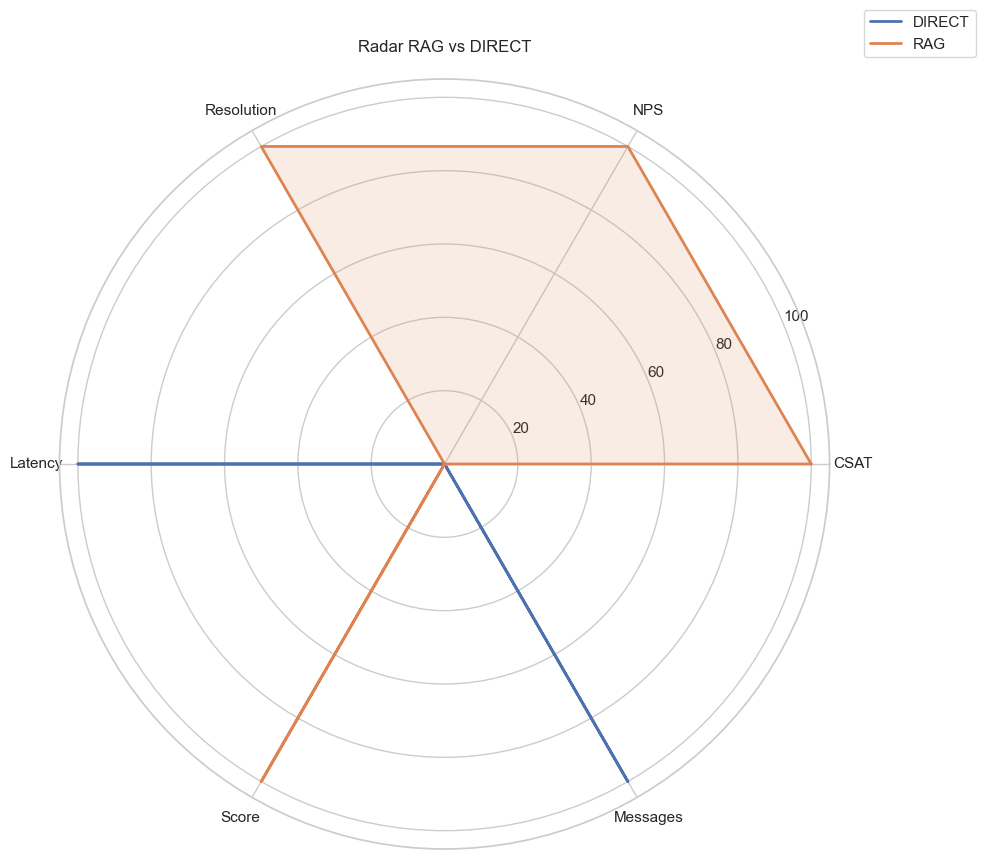

In [18]:
# =====================================================
# BLOQUE J - COMPARACIÓN FINAL EJECUTIVA
# =====================================================

# Radar chart comparando RAG vs DIRECT
# Variables:
# - CSAT
# - NPS
# - Resolution
# - Latency
# - Score Response
# - Mensajes por sesión

import numpy as np

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 10)

# ---------------------------------
# Métricas base
# ---------------------------------

# CSAT
csat = df.groupby("mode")["csat_score"].mean()

# NPS
nps = df.groupby("mode")["nps_score"].mean()

# Resolution
resolution = (
    df.assign(res_ok=np.where(df["resolution_label"] == "yes", 1, 0))
      .groupby("mode")["res_ok"]
      .mean() * 100
)

# Latency (invertida luego)
latency = df.groupby("mode")["latency_ms"].mean()

# Score
score = df.groupby("mode")["score_response"].mean()

# Mensajes por sesión
msg_session = (
    df.groupby(["mode", "session_id"])
      .size()
      .reset_index(name="messages")
      .groupby("mode")["messages"]
      .mean()
)

# ---------------------------------
# Consolidar métricas
# ---------------------------------

metrics = pd.DataFrame({
    "CSAT": csat,
    "NPS": nps,
    "Resolution": resolution,
    "Latency": latency,
    "Score": score,
    "Messages": msg_session
}).fillna(0)

# ---------------------------------
# Normalización 0-100
# Mayor es mejor excepto Latency y Messages
# ---------------------------------

norm = metrics.copy()

for col in norm.columns:
    min_val = norm[col].min()
    max_val = norm[col].max()

    if max_val != min_val:
        norm[col] = (norm[col] - min_val) / (max_val - min_val) * 100
    else:
        norm[col] = 100

# Invertir donde menor es mejor
norm["Latency"] = 100 - norm["Latency"]
norm["Messages"] = 100 - norm["Messages"]

# ---------------------------------
# Radar chart
# ---------------------------------

labels = norm.columns.tolist()
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10,10), subplot_kw=dict(polar=True))

for mode in norm.index:
    values = norm.loc[mode].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=mode)
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_yticks([20,40,60,80,100])
ax.set_yticklabels(["20","40","60","80","100"])

plt.title("Radar RAG vs DIRECT", pad=20)
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

plt.show()